# ClaimWise Insurance Prediction — 08. Hist Gradient Boosting Regressor

## 1. Objective

Train and evaluate the **Hist Gradient Boosting Regressor** — the model whose algorithm was supplied in the
original Google Drive code — that predicts the insurance claim loss `loss` from the 130 preprocessed input
features.

| Item | Location |
|---|---|
| Source code (provided) | `Home_Credit_Default_Risk_FINAL_Perfect.ipynb`, `Home_Credit_Default_Risk_FINAL_FIXED.ipynb` |
| Adapted implementation | `Src/hist_gradient_boosting_regressor_model.py` |
| Training / testing data | `Dataset/06_split_X_train.csv`, `06_split_X_test.csv`, `06_split_y_train.csv`, `06_split_y_test.csv` |
| Shared helpers | `Src/model_training_utils.py` |

The provided notebook is a **binary-classification Kaggle pipeline** (LightGBM, ROC-AUC, 8 Home Credit
tables). Its reusable logic is preserved below; its dataset-specific parts are replaced with the real
ClaimWise data.

## 2. Source Code Mapping (provided code → ClaimWise)

| Provided (Home Credit) | ClaimWise | Why |
|---|---|---|
| `TARGET` binary, ROC-AUC / Gini | `loss` continuous, MAE / MSE / RMSE / R² | ClaimWise predicts a continuous claim amount |
| `LGBMClassifier` | `HistGradientBoostingRegressor` | `lightgbm` is not installed and no network install is allowed; sklearn's histogram GB is the closest equivalent |
| `StratifiedKFold(n_splits=3, shuffle, SEED)` | `KFold(n_splits=3, shuffle, SEED)` | stratification requires a discrete target |
| `num_leaves=31`, `max_depth=-1`, `min_child_samples=50`, `colsample_bytree=0.80`, `reg_lambda=0.50`, `n_estimators=2500` | `max_leaf_nodes=31`, `max_depth=None`, `min_samples_leaf=50`, `max_features=0.80`, `l2_regularization=0.50`, `max_iter=2500` | direct parameter mapping |
| `early_stopping(rounds=150)` + `eval_set` | `early_stopping=True`, `n_iter_no_change=150`, `scoring="loss"`, `X_val`/`y_val` | same patience-based early stopping |
| fold loop, OOF array, fold score reporting | **preserved** in `run_cross_validation()` | core of the provided training logic |
| prediction sanity checks (Cell 17) | **preserved** in `validate_predictions()` | length + finite-value checks |
| `reduce_numeric_memory()` utility | **preserved** in `model_training_utils.py` | dataset independent |
| 6 historical tables + `SK_ID_*` key maps | **not applicable** | ClaimWise is one flat table — no `bureau`, `previous_application`, `POS_CASH_balance`, `credit_card_balance`, `installments_payments` |
| `add_application_features()` ratio columns | **not carried over** | built from Home Credit named fields (`AMT_CREDIT`, `DAYS_BIRTH`, …); ClaimWise columns are anonymised, so replacements would have to be invented |
| `reg_alpha=0.10`, `subsample=0.80` | **dropped** | no sklearn HistGradientBoosting equivalent |
| `submission.csv` for Kaggle | `Models/*.pkl` + `Outputs/…/metrics.csv` | ClaimWise serves predictions through the Flask app, not a Kaggle submission |

This notebook is the single ClaimWise version of that code — `FINAL_Perfect` is superseded by
`FINAL_FIXED` (better previous-application key mapping) and both are represented here.

## 3. Import Libraries

Standard plotting/data libraries, plus the project's shared helpers and the adapted model module.

In [1]:
%matplotlib inline
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    """Walk upwards from the notebook folder until the ClaimWise project is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "Dataset").is_dir() and (candidate / "Src").is_dir():
            return candidate
    raise FileNotFoundError(f"ClaimWise project root not found above: {start}")


PROJECT_ROOT = find_project_root(Path.cwd())
DATASET_DIR = PROJECT_ROOT / "Dataset"
SRC_DIR = PROJECT_ROOT / "Src"
MODELS_DIR = PROJECT_ROOT / "Models"
OUTPUTS_DIR = PROJECT_ROOT / "Outputs"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project root  :", PROJECT_ROOT)
print("Dataset folder:", DATASET_DIR)
print("Src folder    :", SRC_DIR)

from model_training_utils import (
    OUTPUTS_DIR as SHARED_OUTPUTS_DIR,
    calculate_metrics,
    load_prepared_data,
    save_model_diagnostic_plots,
    save_model_results,
)

Project root  : /Users/padaltiruvinayak/Desktop/Credit ML
Dataset folder: /Users/padaltiruvinayak/Desktop/Credit ML/Dataset
Src folder    : /Users/padaltiruvinayak/Desktop/Credit ML/Src


In [3]:
# Src/model_training_utils.py switches matplotlib to the non-interactive Agg backend so the
# command-line scripts can run without a display. Switch back to the inline backend here so
# that every figure below is rendered inside this notebook.
%matplotlib inline

In [4]:
from hist_gradient_boosting_regressor_model import (
    MODEL_FILE,
    MODEL_NAME,
    N_SPLITS,
    OUTPUT_FOLDER,
    SEED,
    build_model,
    run_cross_validation,
    validate_predictions,
)

MODEL_SLUG = "hist_gradient_boosting"
print(MODEL_NAME, "|", MODEL_FILE, "|", OUTPUT_FOLDER)

Hist Gradient Boosting Regressor | hist_gradient_boosting_regressor.pkl | Hist_Gradient_Boosting_Regressor


## 4. Load Dataset — Prepared Train/Test Data

No re-preprocessing happens here: the four prepared files come from `02_ClaimWise_Data_Preprocessing.ipynb`
and are validated by `load_prepared_data()`.

In [5]:
X_train, X_test, y_train, y_test = load_prepared_data()

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)
print("Target column :", y_train.name)
print("Input features:", X_train.shape[1])

X_train: (40000, 130) | X_test: (10000, 130)
y_train: (40000,) | y_test: (10000,)
Target column : loss
Input features: 130


## 5. Verify Train/Test Data

In [6]:
verification = {
    "X_train rows == y_train rows": len(X_train) == len(y_train),
    "X_test rows == y_test rows": len(X_test) == len(y_test),
    "X_train and X_test share the same columns": list(X_train.columns) == list(X_test.columns),
    "target 'loss' is not a feature": "loss" not in X_train.columns,
    "all features are numeric": all(
        pd.api.types.is_numeric_dtype(dtype) for dtype in X_train.dtypes
    ),
    "no missing values in the features": not (
        X_train.isna().any().any() or X_test.isna().any().any()
    ),
    "no missing values in the target": not (y_train.isna().any() or y_test.isna().any()),
}
report = pd.DataFrame(
    [{"check": name, "result": "PASS" if ok else "FAIL"} for name, ok in verification.items()]
)
display(report)

failed = [name for name, ok in verification.items() if not ok]
if failed:
    raise AssertionError(f"Train/test verification failed: {failed}")
print("All", len(verification), "checks passed.")

,check,result
0,X_train rows == y_train rows,PASS
1,X_test rows == y_test rows,PASS
2,X_train and X_test share the same columns,PASS
3,target 'loss' is not a feature,PASS
4,all features are numeric,PASS
5,no missing values in the features,PASS
6,no missing values in the target,PASS


All 7 checks passed.


## 6. Cross-Validation With Early Stopping

The provided notebook trained 3 folds with early stopping and reported out-of-fold (OOF) scores.
The same structure is executed here for the regression target.

In [7]:
cv_start = time.time()
cv_result = run_cross_validation(X_train, y_train)
print(f"Cross-validation finished in {time.time() - cv_start:.1f}s")

Fold 1/3: iterations=830 MAE=1215.3804 RMSE=1950.7341 R2=0.5618


Fold 2/3: iterations=572 MAE=1224.1672 RMSE=1913.9725 R2=0.5349


Fold 3/3: iterations=842 MAE=1204.9775 RMSE=2004.2711 R2=0.5473
Cross-validation finished in 47.5s


In [8]:
cv_result["fold_scores"]

,fold,iterations,MAE,MSE,RMSE,R2
0,1,830,1215.380389,3.805364e+06,1950.734097,0.561836
1,2,572,1224.167246,3.663291e+06,1913.972497,0.534920
2,3,842,1204.977475,4.017103e+06,2004.271149,0.547253


In [9]:
oof_metrics = cv_result["oof_metrics"]
print("Best iterations per fold:", cv_result["fold_iterations"])
print("Median best iteration    :", cv_result["best_iterations"])
print()
print("Out-of-fold metrics (all 40,000 training rows, each row predicted only by models that did not train on it):")
for name, value in oof_metrics.items():
    print(f"  {name:5s} {value:,.6f}")

cv_csv = OUTPUTS_DIR / OUTPUT_FOLDER / "cross_validation_folds.csv"
cv_result["fold_scores"].to_csv(cv_csv, index=False)
print("\nSaved:", cv_csv)

Best iterations per fold: [830, 572, 842]
Median best iteration    : 830

Out-of-fold metrics (all 40,000 training rows, each row predicted only by models that did not train on it):
  MAE   1,214.841717
  MSE   3,828,585.111163
  RMSE  1,956.677058
  R2    0.548424

Saved: /Users/padaltiruvinayak/Desktop/Credit ML/Outputs/Hist_Gradient_Boosting_Regressor/cross_validation_folds.csv


## 7. Create the Final Model

The production model is fitted once on **all** 40,000 training rows using the median best iteration found
by cross-validation (the same pattern as taking LightGBM's `best_iteration_` after early stopping).

In [10]:
best_iter = max(int(cv_result["best_iterations"]), 1)
model = build_model(max_iter=best_iter)
print(model)

HistGradientBoostingRegressor(l2_regularization=0.5, learning_rate=0.035,
                              max_features=0.8, max_iter=830,
                              min_samples_leaf=50, random_state=42)


## 8. Model Training

In [11]:
train_start = time.time()
model.fit(X_train, y_train)
train_seconds = time.time() - train_start
print(f"Trained in {train_seconds:.1f}s | iterations used: {model.n_iter_}")

Trained in 5.4s | iterations used: 224


## 9. Prediction — Provided Sanity Checks

The provided notebook validated every prediction vector before using it. The same checks run here.

In [12]:
y_pred = model.predict(X_test)
validate_predictions(y_test, y_pred)
print("Prediction validation PASSED.")
print("Prediction min / max / mean:",
      round(float(np.min(y_pred)), 4),
      round(float(np.max(y_pred)), 4),
      round(float(np.mean(y_pred)), 4))

Prediction validation PASSED.
Prediction min / max / mean: 635.9895 20256.4937 3002.6232


## 10. Evaluation — Regression Metrics

In [13]:
metrics = calculate_metrics(y_test, y_pred)
print("Hist Gradient Boosting Regressor test-set metrics:")
for name, value in metrics.items():
    print(f"  {name:5s} {value:,.6f}")

Hist Gradient Boosting Regressor test-set metrics:
  MAE   1,215.299703
  MSE   3,690,333.116474
  RMSE  1,921.023976
  R2    0.545901


## 11. Visualization — Actual vs Predicted and Residuals

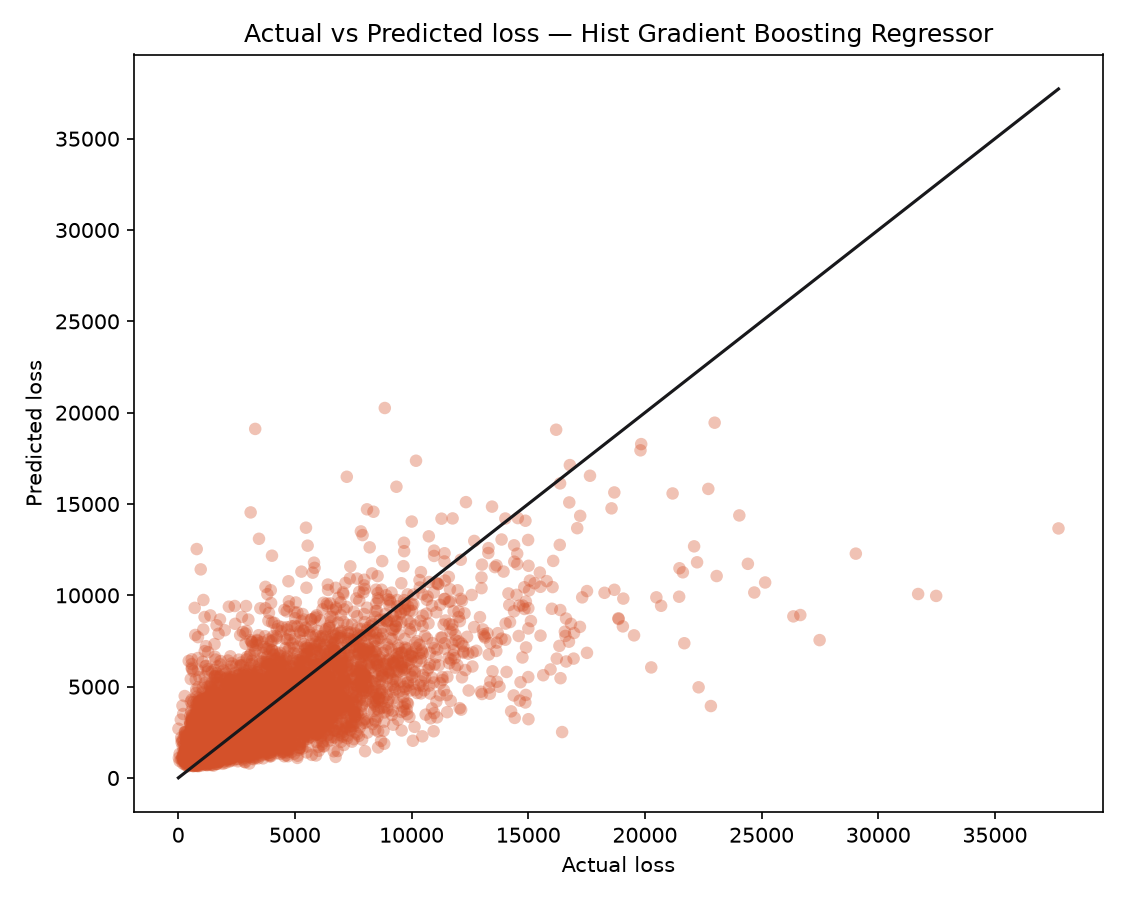

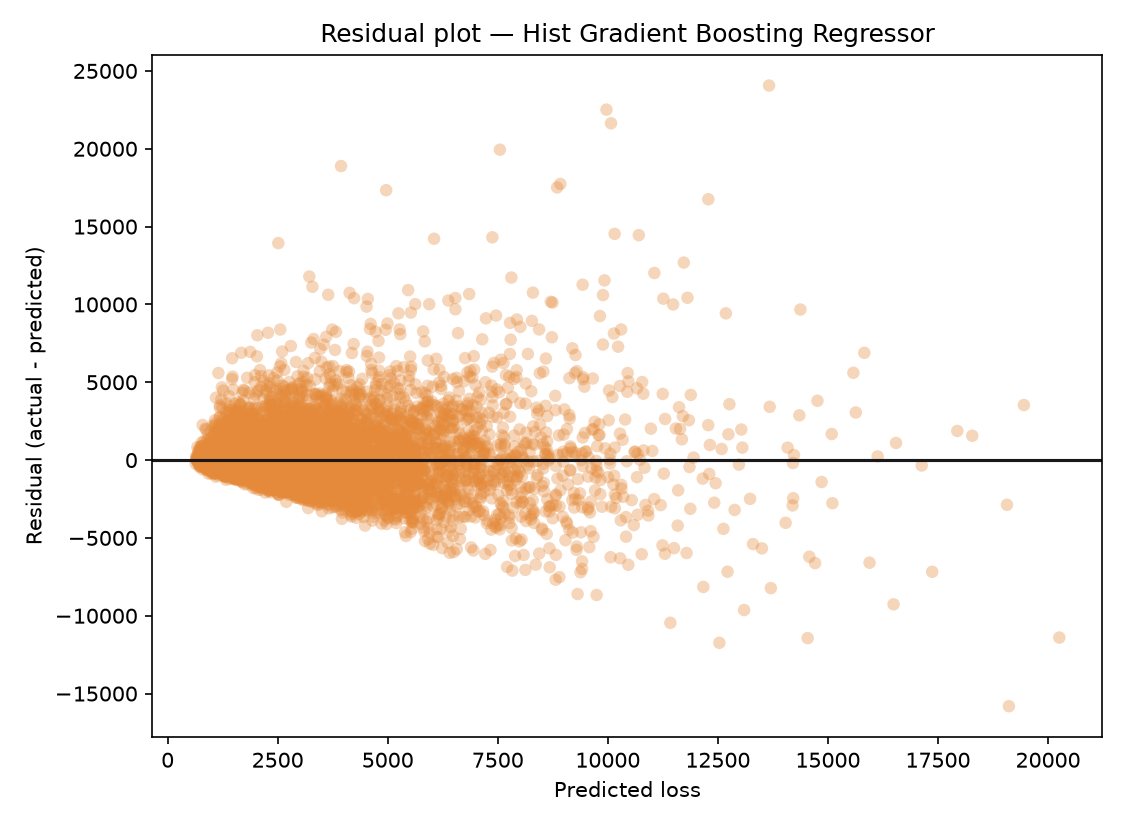

In [14]:
model_output_dir = OUTPUTS_DIR / OUTPUT_FOLDER
save_model_diagnostic_plots(MODEL_NAME, OUTPUT_FOLDER, y_test, y_pred)

from IPython.display import Image, display
for figure_name in [
    f"{OUTPUT_FOLDER.lower()}_actual_vs_predicted.png",
    f"{OUTPUT_FOLDER.lower()}_residuals.png",
]:
    display(Image(filename=str(model_output_dir / figure_name)))

## 12. Save Results

In [15]:
saved_metrics = save_model_results(
    MODEL_NAME,
    MODEL_FILE,
    model,
    X_test,
    y_test,
    y_pred,
)
print("Saved model :", MODELS_DIR / MODEL_FILE)
print("Saved metrics:", model_output_dir / "metrics.csv")
print("Saved predictions:", model_output_dir / "predictions.csv")
print("Metrics:", saved_metrics)

Saved model : /Users/padaltiruvinayak/Desktop/Credit ML/Models/hist_gradient_boosting_regressor.pkl
Saved metrics: /Users/padaltiruvinayak/Desktop/Credit ML/Outputs/Hist_Gradient_Boosting_Regressor/metrics.csv
Saved predictions: /Users/padaltiruvinayak/Desktop/Credit ML/Outputs/Hist_Gradient_Boosting_Regressor/predictions.csv
Metrics: {'MAE': 1215.299702959891, 'MSE': 3690333.1164736343, 'RMSE': 1921.0239760277939, 'R2': 0.5459011973814277}


## 13. Conclusion

Hist Gradient Boosting Regressor — the model taken from the provided Google Drive code — was trained on the
40,000 prepared training rows and evaluated on the 10,000 held-out test rows. Actual results of this run:

| Model | MAE | MSE | RMSE | R² |
|---|---:|---:|---:|---:|
| Hist Gradient Boosting Regressor | 1215.2997 | 3690333.1165 | 1921.0240 | 0.545901 |

Cross-validation (3 folds, early stopping) reached out-of-fold RMSE **1956.6771** and R² **0.548424**, with
per-fold iteration counts `[830, 572, 842]`.

Artifacts: `Models/hist_gradient_boosting_regressor.pkl`,
`Outputs/Hist_Gradient_Boosting_Regressor/metrics.csv`, `predictions.csv`,
`cross_validation_folds.csv` and the two diagnostic charts.

All five models are compared in `09_ClaimWise_Model_Comparison.ipynb`.